🚨 Détection d'Anomalies dans les Ventes

## Objectif
Identifier automatiquement les transactions anormales pour prévenir fraudes, erreurs système, ou dysfonctionnements business.

## Techniques ML
- **Isolation Forest** : Algorithme détection anomalies
- **Z-Score** : Détection statistique écarts
- **IQR** : Méthode des quartiles

## Business Value
✅ Détection fraudes temps réel
✅ Alerte bugs systèmes
✅ Identification opportunités business
✅ Monitoring qualité données


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

# Créer données synthétiques Superstore
np.random.seed(42)
n = 1000

dates = pd.date_range('2023-01-01', periods=n, freq='D')
sales = np.random.lognormal(5, 1, n) # Distribution normale log

# Injecter anomalies
anomaly_indices = np.random.choice(n, 30, replace=False)
sales[anomaly_indices] *= np.random.choice([0.1, 5], 30)

df = pd.DataFrame({
    'Order Date': dates,
    'Sales': sales,
    'Order ID': [f'ORD-{i:05d}' for i in range(n)]
})

print(f"Dataset : {len(df)} transactions")
print(f"Periode : {df['Order Date'].min()} - {df['Order Date'].max()}")
print(f"Ventes totales : {df['Sales'].sum():,.2f} euros\n")
df.head()


Dataset : 1000 transactions
Periode : 2023-01-01 00:00:00 - 2025-09-26 00:00:00
Ventes totales : 268,530.56 euros



,Order Date,Sales,Order ID
0,2023-01-01,243.889232,ORD-00000
1,2023-01-02,129.248344,ORD-00001
2,2023-01-03,283.635096,ORD-00002
3,2023-01-04,680.637498,ORD-00003
4,2023-01-05,117.430495,ORD-00004


STATISTIQUES VENTES

count     1000.000000
mean       268.530563
std        625.703139
min          4.468794
25%         77.058368
50%        151.829555
75%        285.691653
max      16128.105639
Name: Sales, dtype: float64


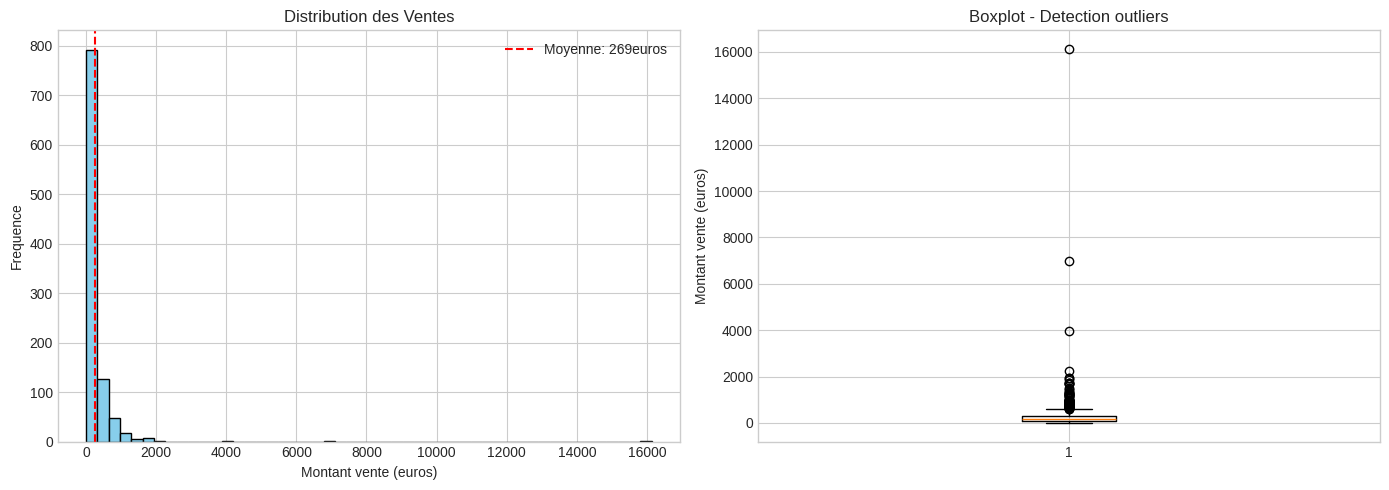

In [2]:
#Stats descriptives
print("STATISTIQUES VENTES\n")
print(df['Sales'].describe())

# Visualisation distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Sales'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Montant vente (euros)')
axes[0].set_ylabel('Frequence')
axes[0].set_title('Distribution des Ventes')
axes[0].axvline(df['Sales'].mean(), color='red', linestyle='--', 
                label=f'Moyenne: {df["Sales"].mean():.0f}euros')
axes[0].legend()

axes[1].boxplot(df['Sales'], vert=True)
axes[1].set_ylabel('Montant vente (euros)')
axes[1].set_title('Boxplot - Detection outliers')

plt.tight_layout()
plt.show()

Isolation Forest : 30 anomalies detectees (3.0%)



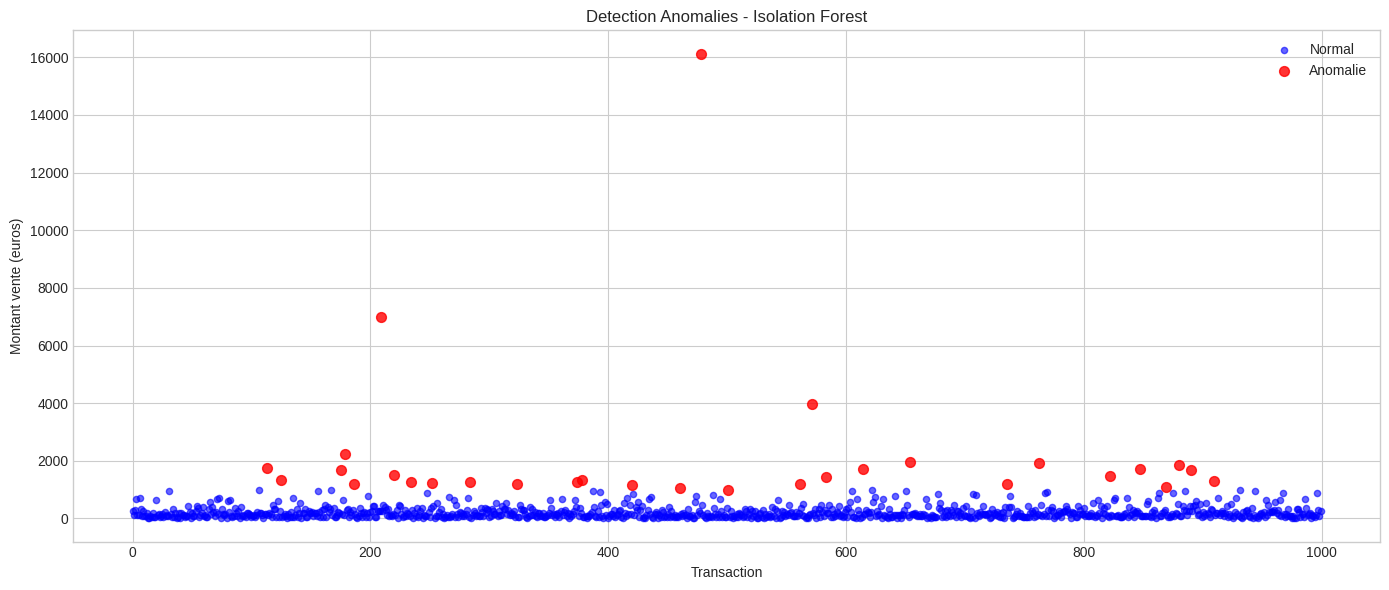

In [3]:
#Isolation Forest
iso_forest = IsolationForest(contamination=0.03, random_state=42)
df['Anomaly_IF'] = iso_forest.fit_predict(df[['Sales']])

# -1 = anomalie, 1 = normal
df['Is_Anomaly_IF'] = df['Anomaly_IF'] == -1

nb_anomalies = df['Is_Anomaly_IF'].sum()
print(f"Isolation Forest : {nb_anomalies} anomalies detectees ({nb_anomalies/len(df)*100:.1f}%)\n")

# Visualisation
plt.figure(figsize=(14, 6))
plt.scatter(df.index[~df['Is_Anomaly_IF']], 
            df['Sales'][~df['Is_Anomaly_IF']], 
            c='blue', alpha=0.6, label='Normal', s=20)
plt.scatter(df.index[df['Is_Anomaly_IF']], 
            df['Sales'][df['Is_Anomaly_IF']], 
            c='red', alpha=0.8, label='Anomalie', s=50)
plt.xlabel('Transaction')
plt.ylabel('Montant vente (euros)')
plt.title('Detection Anomalies - Isolation Forest')
plt.legend()
plt.tight_layout()
plt.show()


In [4]:
#Z-Score (seuil = 3)
df['Z_Score'] = np.abs(stats.zscore(df['Sales']))
df['Is_Anomaly_Z'] = df['Z_Score'] > 3

nb_anomalies_z = df['Is_Anomaly_Z'].sum()
print(f"Z-Score : {nb_anomalies_z} anomalies detectees\n")

# Top 10 anomalies
print("TOP 10 ANOMALIES (Z-Score)\n")
top_anomalies = df[df['Is_Anomaly_Z']].nlargest(10, 'Sales')
print(top_anomalies[['Order ID', 'Order Date', 'Sales', 'Z_Score']])

Z-Score : 4 anomalies detectees

TOP 10 ANOMALIES (Z-Score)

      Order ID Order Date         Sales    Z_Score
478  ORD-00478 2024-04-23  16128.105639  25.359487
209  ORD-00209 2023-07-29   6993.465490  10.753182
571  ORD-00571 2024-07-25   3967.435617   5.914555
179  ORD-00179 2023-06-29   2253.340738   3.173715


In [5]:
#IQR (Interquartile Range)
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['Is_Anomaly_IQR'] = (df['Sales'] < lower_bound) | (df['Sales'] > upper_bound)

nb_anomalies_iqr = df['Is_Anomaly_IQR'].sum()
print(f"IQR Method : {nb_anomalies_iqr} anomalies detectees")
print(f"Seuils : [{lower_bound:.2f} - {upper_bound:.2f}] euros\n")

IQR Method : 93 anomalies detectees
Seuils : [-235.89 - 598.64] euros



COMPARAISON METHODES

            Methode  Nb_Anomalies
0  Isolation Forest            30
1           Z-Score             4
2               IQR            93


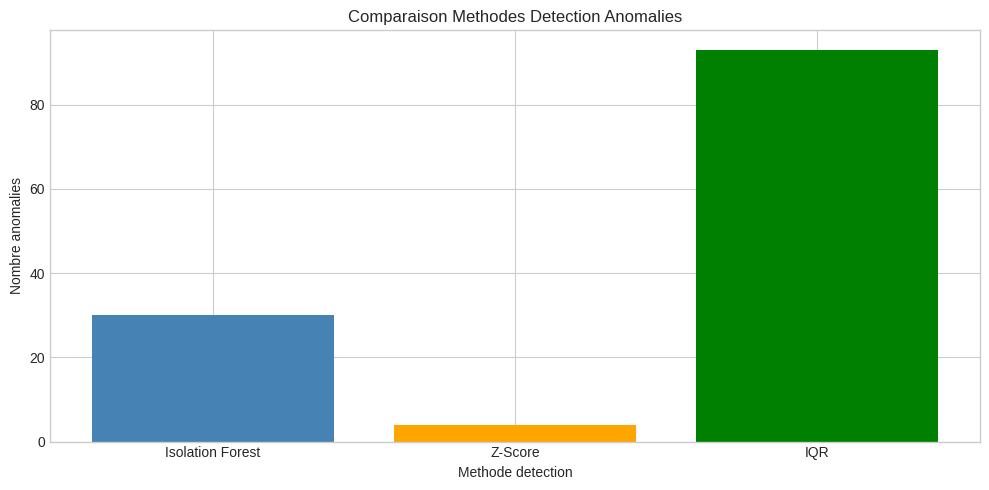

In [6]:
#Comparaison 3 methodes
comparison = pd.DataFrame({
    'Methode': ['Isolation Forest', 'Z-Score', 'IQR'],
    'Nb_Anomalies': [
        df['Is_Anomaly_IF'].sum(),
        df['Is_Anomaly_Z'].sum(),
        df['Is_Anomaly_IQR'].sum()
    ]
})

print("COMPARAISON METHODES\n")
print(comparison)

# Graphique
plt.figure(figsize=(10, 5))
plt.bar(comparison['Methode'], comparison['Nb_Anomalies'], color=['steelblue', 'orange', 'green'])
plt.xlabel('Methode detection')
plt.ylabel('Nombre anomalies')
plt.title('Comparaison Methodes Detection Anomalies')
plt.tight_layout()
plt.show()

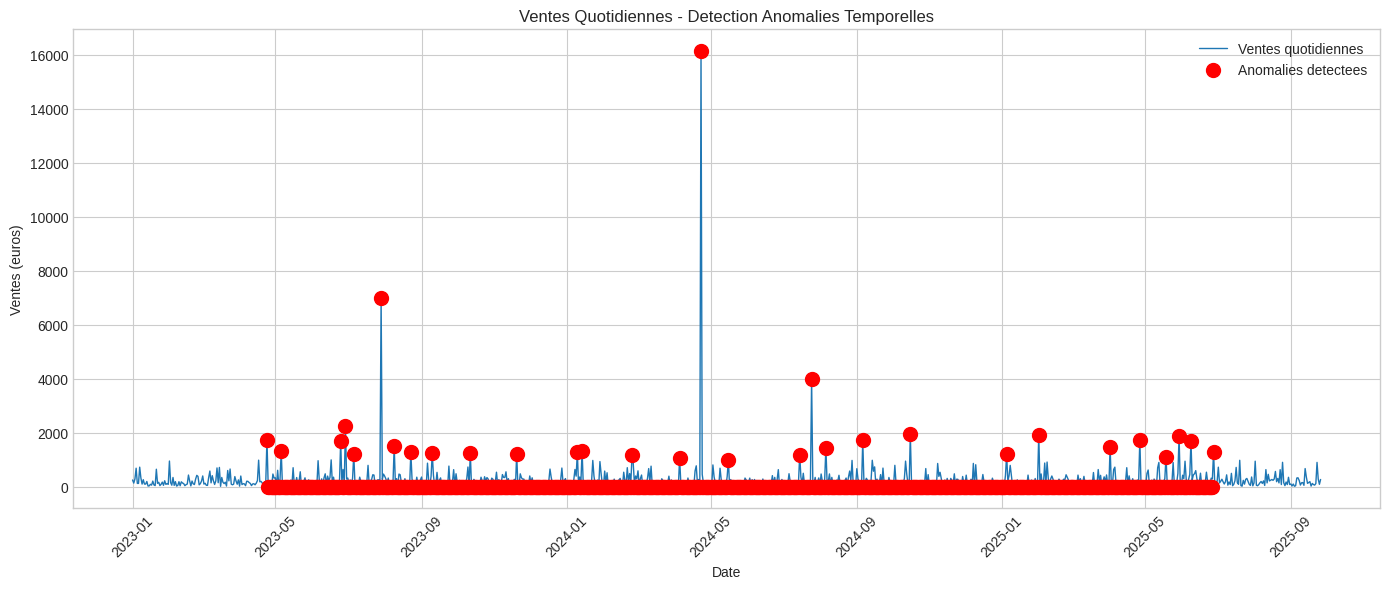

In [7]:
#Analyse temporelle
df_daily = df.set_index('Order Date').resample('D')['Sales'].sum().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(df_daily['Order Date'], df_daily['Sales'], label='Ventes quotidiennes', linewidth=1)

# Marquer anomalies
anomalies_dates = df[df['Is_Anomaly_IF']].set_index('Order Date').resample('D')['Sales'].sum()
plt.scatter(anomalies_dates.index, anomalies_dates.values, 
            color='red', s=100, label='Anomalies detectees', zorder=5)

plt.xlabel('Date')
plt.ylabel('Ventes (euros)')
plt.title('Ventes Quotidiennes - Detection Anomalies Temporelles')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
#CELLULE


In [8]:
#Recommandations business
print("="*60)
print("RECOMMANDATIONS ACTIONS")
print("="*60)

anomalies_high = df[(df['Is_Anomaly_IF']) & (df['Sales'] > df['Sales'].median())]
anomalies_low = df[(df['Is_Anomaly_IF']) & (df['Sales'] <= df['Sales'].median())]

print(f"\nAnomalies HAUTES ({len(anomalies_high)}) :")
print(" Action : Verifier legitimite transactions")
print(" Causes possibles : Fraude, erreur saisie, opportunite business")
print(f" Montant moyen : {anomalies_high['Sales'].mean():,.2f} euros")

print(f"\nAnomalies BASSES ({len(anomalies_low)}) :")
print(" Action : Analyser causes baisse")
print(" Causes possibles : Bug systeme, promotion excessive, erreur stock")
print(f" Montant moyen : {anomalies_low['Sales'].mean():,.2f} euros")

print(f"\nTaux anomalies global : {len(df[df['Is_Anomaly_IF']])/len(df)*100:.1f}%")
print(" Seuil acceptable : < 5%")
print(" Recommandation : Monitoring continu + alertes temps reel")

RECOMMANDATIONS ACTIONS

Anomalies HAUTES (30) :
 Action : Verifier legitimite transactions
 Causes possibles : Fraude, erreur saisie, opportunite business
 Montant moyen : 2,204.37 euros

Anomalies BASSES (0) :
 Action : Analyser causes baisse
 Causes possibles : Bug systeme, promotion excessive, erreur stock
 Montant moyen : nan euros

Taux anomalies global : 3.0%
 Seuil acceptable : < 5%
 Recommandation : Monitoring continu + alertes temps reel
